<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>آموزش مدل دتکشن بر اساس پنجره لغزان</b>
  </p>
</div>

---

<div dir="rtl" style="text-align: right;">
کلاس مدل طبقه‌بندی:
</div>

In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F 


class Model(nn.Module):
   
    def __init__(self):
        super(Model,self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride = 2)
        self.conv3 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride = 2)
        self.conv4 = nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3)
        self.conv5 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=1)
        self.conv6 = nn.Conv2d(in_channels=128,out_channels=1,kernel_size=1)


    def forward(self,x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))

        x = self.conv6(x)
    
        return x

model = Model()

In [88]:
print(model)

Model(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  (conv6): Conv2d(128, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [89]:
x = torch.randn(1, 3, 28, 28)
y = model(x)
print(y.shape)

torch.Size([1, 1, 1, 1])


In [90]:
device = '"cuda' if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [91]:
model = Model().to(device)
x = torch.randn(1, 3, 28, 28).to(device)
y = model(x)
print(y.shape)

torch.Size([1, 1, 1, 1])


---

<div dir="rtl" style="text-align: right;">
دانلود پایگاه داده wider face:
</div>

http://shuoyang1213.me/WIDERFACE/

---

<div dir="rtl" style="text-align: right;">
ایجاد کردن دیتالودر
    
    https://github.com/spacewalk01/yolov9-face-detection/blob/main/train2yolo.py
</div>

In [68]:
import cv2
import torch.utils.data as data
import numpy as np


class WiderFaceDetection(data.Dataset):
    def __init__(self, txt_path, img_path, preproc=None):
        self.preproc = preproc
        self.imgs_path = []
        self.words = []
        f = open(txt_path, 'r')
        lines = f.readlines()
        isFirst = True
        labels = []
        for line in lines:
            line = line.rstrip()
            if line.endswith('jpg'):
                if isFirst is True:
                    isFirst = False
                else:
                    labels_copy = labels.copy()
                    self.words.append(labels_copy)
                    labels.clear()
                path = line
                path = img_path + path
                self.imgs_path.append(path)
            else:
                line = line.split(' ')
                if len(line) > 1:
                    label = [int(x) for x in line]
                    labels.append(label)

        self.words.append(labels)

    def __len__(self):
        return len(self.imgs_path)

    def __getitem__(self, index):
        # print(self.imgs_path[index])
        img = cv2.imread(self.imgs_path[index])
        height, width, _ = img.shape

        labels = self.words[index]
        annotations = np.zeros((0, 4)).astype(int)
        if len(labels) == 0:
            return annotations
        for idx, label in enumerate(labels):
            annotation = np.zeros((1, 4)).astype(int)
            # bbox
            annotation[0, 0] = label[0]  # x1
            annotation[0, 1] = label[1]  # y1
            annotation[0, 2] = label[0] + label[2]  # x2
            annotation[0, 3] = label[1] + label[3]  # y2

            annotations = np.append(annotations, annotation, axis=0)
        target = np.array(annotations)
        if self.preproc is not None:
            img, target = self.preproc(img, target) #torch.from_numpy

        return img, target

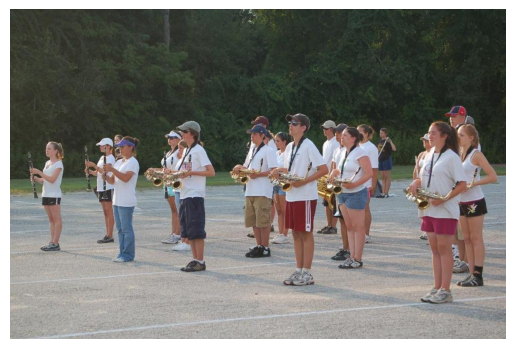

In [93]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

txt_path = '../notebooks-data/wider_face_split/wider_face_train_bbx_gt.txt'
img_path = '../notebooks-data/WIDER_train/images/'

train_data = WiderFaceDetection(txt_path, img_path)
image, label = train_data.__getitem__(15)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')  # Turn off axis labels for cleaner display
plt.show()

<div dir="rtl" style="text-align: right;">
ساختن دو دیتالودر:
    
- یکی از هر تصویر یکی از چهره‌ها در تصویر را بصورت تصادفی انتخاب میکند
- در دیگری یک برش تصادفی از تصویر انتخاب میکند
- سپس یک دیتالودر دیگر از دو دیتالودر میسازد که با یک احتمال از دو دیتالودر انتخاب میکند
</div>

In [94]:
class WiderFaceLoad(WiderFaceDetection):
    def __init__(self, txt_path, img_path, preproc = None, maxsize = 28, maxshift = 4):
        super().__init__(txt_path, img_path, preproc)
        self.maxsize = maxsize
        self.maxshift = maxshift
    
    def __len__(self):
        return super().__len__()
        
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        height, width, _ = img.shape
        rows = target.shape[0]
        imgbox = None
        if rows > 0:
            permuted_range = np.random.permutation(rows)
        for boxnum in permuted_range:
            box_height = target[boxnum,3] - target[boxnum,1]
            box_width = target[boxnum,2] - target[boxnum,0]
            if box_width <= self.maxsize or box_height <= self.maxsize:
                center_y = (target[boxnum,0] + target[boxnum,2]) // 2
                center_x = (target[boxnum,1] + target[boxnum,3]) // 2
                beg_x = center_x - self.maxsize // 2
                end_x = center_x + self.maxsize // 2
                beg_y = center_y - self.maxsize // 2
                end_y = center_y + self.maxsize // 2
                if beg_x >= 0 and end_x <= height and beg_y >= 0 and end_y <= width:
                    imgbox = img[beg_x:end_x,beg_y:end_y,:]
                    break

        return imgbox
    

In [95]:
train_data = WiderFaceLoad(txt_path, img_path)
image = train_data.__getitem__(15)
if image is not None:
    _, imdata = cv2.imencode('.jpg', image) 
    i = Image(data = imdata)
    display(i)

In [96]:
class WiderFaceRandom(WiderFaceDetection):
    def __init__(self, txt_path, img_path, preproc = None, maxsize = 28):
        super().__init__(txt_path, img_path, preproc)
        self.maxsize = maxsize
    
    def __len__(self):
        return super().__len__()
        
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        height, width, _ = img.shape
        random_x = np.random.randint(height-self.maxsize)
        random_y = np.random.randint(width-self.maxsize)
        imgbox = img[random_x:random_x+self.maxsize,random_y:random_y+self.maxsize,:]
        # It is unlikely but one can check if random box overlaps face boxes
        
        return imgbox

In [97]:
train_data = WiderFaceRandom(txt_path, img_path)
image = train_data.__getitem__(15)
print(image.shape)
if image is not None:
    _, imdata = cv2.imencode('.jpg', image) 
    i = Image(data = imdata)
    display(i)

(28, 28, 3)


In [98]:
class FaceDataLoader(data.Dataset):
    def __init__(self, txt_path, img_path, preproc = None, maxsize = 28, maxshift = 4, prob = 0.5):
        self.data1 = WiderFaceLoad(txt_path, img_path, preproc, maxsize = 28, maxshift = 4)
        self.data2 = WiderFaceRandom(txt_path, img_path, preproc, maxsize = 28)
        self.prob = prob
    
    def __len__(self):
        return self.data1.__len__()
        
    def __getitem__(self, index):
        rand = np.random.rand()
        if rand < self.prob:
            imgbox = self.data1.__getitem__(index)
            label = torch.tensor(1).float()
        if rand >= self.prob or imgbox is None:
            imgbox = self.data2.__getitem__(index)
            label = torch.tensor(0).float()
        return torch.from_numpy(imgbox/255.0).float().permute(2, 0, 1), label

In [99]:
training_set = FaceDataLoader(txt_path, img_path, prob = 0.3)
image, label = training_set.__getitem__(15)
_, imdata = cv2.imencode('.jpg', image.permute(1, 2, 0).numpy()*255) 
i = Image(data = imdata)
display(i)
print(label)

tensor(0.)


<div dir="rtl" style="text-align: right;">
تعریف پارامترها و بهینه ساز و تابع هزینه
</div>

In [105]:
import torch.optim as optim 

# DECLARING VARIABLES
epochs = 150
batch_size = 32
printfreq = 100

# LOADING THE MODEL
model = Model()

#LOSS FUNCTION
lossfunc = nn.BCEWithLogitsLoss(reduction='mean')

#OPTIMIZER
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)

#SCHEDULER
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,            # initial restart period (epochs)
    T_mult=2,          # factor by which T_0 increases after each restart
    eta_min=1e-4     
)

<div dir="rtl" style="text-align: right;">
کد آموزش شبکه
</div>

In [ ]:
training_loader = data.DataLoader(training_set, batch_size=batch_size, shuffle=True)
for e in range(0, epochs):
    
    train_loss = 0.0
    running_loss = 0.0
    valid_loss = 0.0

    for i, sample in enumerate(training_loader):
        x,y = sample  
        optimizer.zero_grad() # zeroes the gradient buffers of all parameters
        output = model(x)
        output = output.view(-1) #reshaping the tensor while being unsure of no of rows
        loss = lossfunc(output,y)
        running_loss += loss.item()
        train_loss += loss.item() # TENSOR TO SCALAR

        loss.backward()
        optimizer.step()

        if (i+1)%printfreq==0:
            print(f" Epoch: {e+1}, Batch: {i+1}, Running Loss: {running_loss/printfreq}")
            running_loss=0.0

    scheduler.step()
    print(f"Epoch: {e+1}, Train Loss: {train_loss/len(training_loader)}, Learning rate: {scheduler.get_last_lr()[0]} ")
    print("-----")
    
print('Training Complete')

<div dir="rtl" style="text-align: right;">
ذخیره و بازیابی نموپن وزنهای مدل
</div>

In [110]:
save = False
PATH = "model_weights.pth"
if save:
    torch.save(model.state_dict(), PATH)
else:
    model.load_state_dict(torch.load(PATH))

<div dir="rtl" style="text-align: right;">
اعمال مدل بر روی یکی از دادگان اعتبار سنجی
</div>

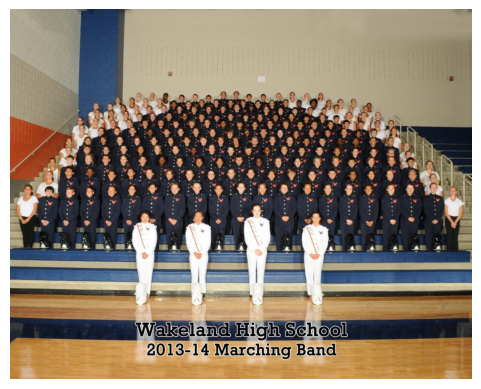

torch.Size([1, 3, 820, 1024])
(199, 250)


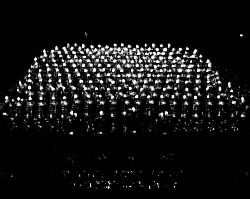

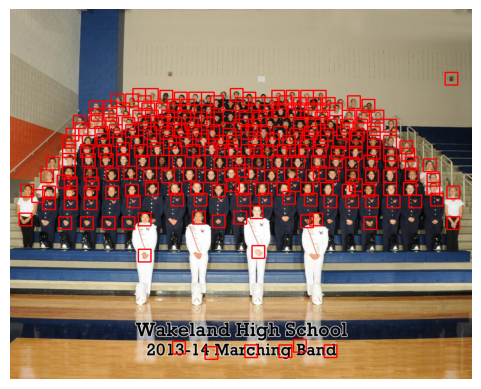

In [108]:
from skimage.feature import peak_local_max

txt_path = '../notebooks-data/wider_face_split/wider_face_val_bbx_gt.txt'
img_path = '../notebooks-data/WIDER_val/images/'

valid_data = WiderFaceDetection(txt_path, img_path)
image, label = valid_data.__getitem__(15)

conf = 0.9

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')  
plt.show()

imtorch = torch.from_numpy(image/255.0).float().permute(2, 0, 1).unsqueeze(0)
print(imtorch.shape)
model.eval()

result = torch.sigmoid(model(imtorch)).detach().squeeze().numpy() 
print(result.shape)

_, imdata = cv2.imencode('.jpg', result* 255) 
i = Image(data = imdata)
display(i)

coordinates = peak_local_max(result, min_distance=3)

for coordinate in coordinates:
    start_point = (coordinate[1]*4, coordinate[0]*4) 
    end_point = (coordinate[1]*4+28, coordinate[0]*4+28) 
    color = (255, 0, 0)   
    thickness = 2         
    if result[coordinate[0],coordinate[1]]> conf:
        cv2.rectangle(image_rgb, start_point, end_point, color, thickness)

plt.imshow(image_rgb)
plt.axis('off')  
plt.show()


<div dir="rtl" style="text-align: right;">
<h3 style="text-align: right;">
تمرین
</h3>

- برای کوچکتر شدن مدل به جای کانولوشن معمولی از کانولوشن تفکیک‌پذیر عمقی استفاده کنید
- از نرمالیزه کردن بسته استفاده کنید
- با مدل جدید شبکه را آموزش داده و نتایج را گزارش دهید
</div>

<div dir="rtl" style="text-align: right;">
<h3 style="text-align: right;">
مواردی که میتوان مدل را بهبود داد
</h3>

- در آموزش در چندین مقیاس از تصویر استفاده شود
- خطای داده اعتبارسنجی هم در آموزش رصد شود
- دیتالودر بهتری نوشته شود
- از ماین کردن داده‌های منفی سخت استفاده شود
    - بر روی داده‌های آموزش مدل اعمال شود و هر جا اشتباه چهره تشخیص داده شد مشخص شود
    - در دیتالودر با یک احتمال از چنین داده‌هایی بعنوان داده منفی استفاده شود
    - مدل مجددا آموزش داده شود
- استفاده کردن از مدلهای پیش‌آموزش دیده
- تخمین باندینگ باکس برای موقعیت‌یابی دقیقتر
- استفاده کردن از حالت آبشاری یا کسکید
</div>

<div dir="rtl" style="text-align: right;">
<h3 style="text-align: right;">
تمرین داوطلبانه برای هفته بعد
</h3>

- در آموزش در چندین مقیاس از تصویر استفاده کنید
- از ماین کردن داده‌های منفی سخت استفاده کنید
- مدل آموزش داده شده را بر روی چند تصویر آزمایش کنید و نتایج را گزارش دهید
- معیار ارزیابی mAP را گزارش دهید  
</div>